# **Capstone Project:** Medicine Details Analysis
---

# Introduction


**Problem Statement:**

- The pharmaceutical industry faces the challenge of managing vast amounts of data related to the composition, uses, and side effects of medicines. As the number of available medications continues to grow, healthcare providers need reliable insights to prescribe the most effective treatments while minimizing adverse effects.

- Additionally, understanding the distribution of medicine usage and patient
satisfaction can help pharmaceutical companies improve their offerings.
Your task is to analyze a dataset containing detailed information about over 11,000 medicines, including their salt compositions, uses, side effects, manufacturers, and user reviews.

- The goal is to uncover patterns and insights that can help improve
decision-making in the healthcare industry and enhance patient outcomes by investigating these 3 objectives:

 - Gain insights into the factors that influence medicine effectiveness and patient satisfaction.
 - Identify the most common side effects and their associated medicines.
 - Predict user satisfaction ratings with high accuracy using the given features.


In [ ]:
#install libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Data Preprocessing

In [ ]:
# Load the dataset

data = pd.read_csv('Medicine_Details.csv')
print(data.head())

              Medicine Name  \
0   Avastin 400mg Injection   
1  Augmentin 625 Duo Tablet   
2       Azithral 500 Tablet   
3          Ascoril LS Syrup   
4         Aciloc 150 Tablet   

                                         Composition  \
0                                Bevacizumab (400mg)   
1    Amoxycillin  (500mg) +  Clavulanic Acid (125mg)   
2                               Azithromycin (500mg)   
3  Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...   
4                                 Ranitidine (150mg)   

                                                Uses  \
0   Cancer of colon and rectum Non-small cell lun...   
1                  Treatment of Bacterial infections   
2                  Treatment of Bacterial infections   
3                      Treatment of Cough with mucus   
4  Treatment of Gastroesophageal reflux disease (...   

                                        Side_effects  \
0  Rectal bleeding Taste change Headache Noseblee...   
1  Vomiting Nausea Diarrhea

# Handling Missing Values & Summary Statistics

In [ ]:
# Check for missing values
missing_values = data.isnull().sum()

# Check for duplicates
duplicate_rows = data.duplicated().sum()

# Display results
missing_values, duplicate_rows

(Medicine Name         0
 Composition           0
 Uses                  0
 Side_effects          0
 Image URL             0
 Manufacturer          0
 Excellent Review %    0
 Average Review %      0
 Poor Review %         0
 dtype: int64,
 84)

In [ ]:
# Check for duplicated entries in the dataset
duplicated_entries = data[data.duplicated()]

# Count the number of duplicated entries
num_duplicates = duplicated_entries.shape[0]
num_duplicates

84

In [ ]:
# Remove the duplicated entries
medicine_data_cleaned = data.drop_duplicates()

# Confirm the duplicates are removed by checking the number of duplicates again
remaining_duplicates = medicine_data_cleaned.duplicated().sum()

# Display the number of remaining duplicates to confirm
remaining_duplicates


0

In [ ]:
# Select only numeric columns
numeric_data = medicine_data_cleaned.select_dtypes(include=['float64', 'int64'])

# Compute mean, median, mode, and standard deviation for numeric columns

mean_values = numeric_data.mean()
median_values = numeric_data.median()
mode_values = numeric_data.mode().iloc[0]
std_values = numeric_data.std()

# Combine into a DataFrame
stats_df = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values,
    'Standard Deviation': std_values
})

# Display the DataFrame
print(stats_df)

# Basic statistics
basic_stats = data.describe()
print(basic_stats)

                         Mean  Median  Mode  Standard Deviation
Excellent Review %  38.505068    34.0     0           25.192156
Average Review %    35.783494    35.0    33           18.264038
Poor Review %       25.711439    22.0     0           23.949109
       Excellent Review %  Average Review %  Poor Review %
count        11825.000000      11825.000000   11825.000000
mean            38.516025         35.756364      25.727611
std             25.225343         18.268134      23.991985
min              0.000000          0.000000       0.000000
25%             22.000000         27.000000       0.000000
50%             34.000000         35.000000      22.000000
75%             51.000000         47.000000      35.000000
max            100.000000         88.000000     100.000000


# Feature Engineering

In [ ]:
# Initialize a new DataFrame for the cleaned data
medicine_data_cleaned = medicine_data_cleaned.copy()

# Extract key components from the "Composition" column
# Split the composition column into separate components
medicine_data_cleaned['Components'] = medicine_data_cleaned['Composition'].apply(lambda x: [comp.strip() for comp in x.split('+')])

# Create a new feature for the number of components in each medicine
medicine_data_cleaned['Number_of_Components'] = medicine_data_cleaned['Components'].apply(len)

# Categorize side effects into mild, moderate, and severe based on the frequency of occurrence
# This is a basic categorization; we might refine this further later
medicine_data_cleaned['Side_Effect_Count'] = medicine_data_cleaned['Side_effects'].apply(lambda x: len(x.split()))

# Creating a simple severity categorization based on the number of side effects
def categorize_side_effects(count):
    if count <= 2:
        return 'Mild'
    elif 3 <= count <= 5:
        return 'Moderate'
    else:
        return 'Severe'

medicine_data_cleaned['Side_Effect_Severity'] = medicine_data_cleaned['Side_Effect_Count'].apply(categorize_side_effects)

# Calculate a weighted satisfaction score
medicine_data_cleaned['Weighted_Satisfaction_Score'] = (
    (medicine_data_cleaned['Excellent Review %'] * 3 + medicine_data_cleaned['Average Review %'] * 2 + medicine_data_cleaned['Poor Review %']) / 6
)


# Exploratory Data Analysis

In [ ]:
# Select only numeric columns
numeric_data = medicine_data_cleaned.select_dtypes(include=['float64', 'int64'])

# Compute mean, median, mode, and standard deviation for numeric columns

mean_values = numeric_data.mean()
median_values = numeric_data.median()
mode_values = numeric_data.mode().iloc[0]
std_values = numeric_data.std()

# Combine into a DataFrame
stats_df = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values,
    'Standard Deviation': std_values
})

# Display the DataFrame
print(stats_df)

                             Mean  Median   Mode  Standard Deviation
Excellent Review %      38.516025   34.00   0.00           25.225343
Average Review %        35.756364   35.00  33.00           18.268134
Poor Review %           25.727611   22.00   0.00           23.991985
Aggregate Review Score   2.127884    2.13   2.67            0.457181
Side Effect Count       13.909598   11.00   8.00            9.709918


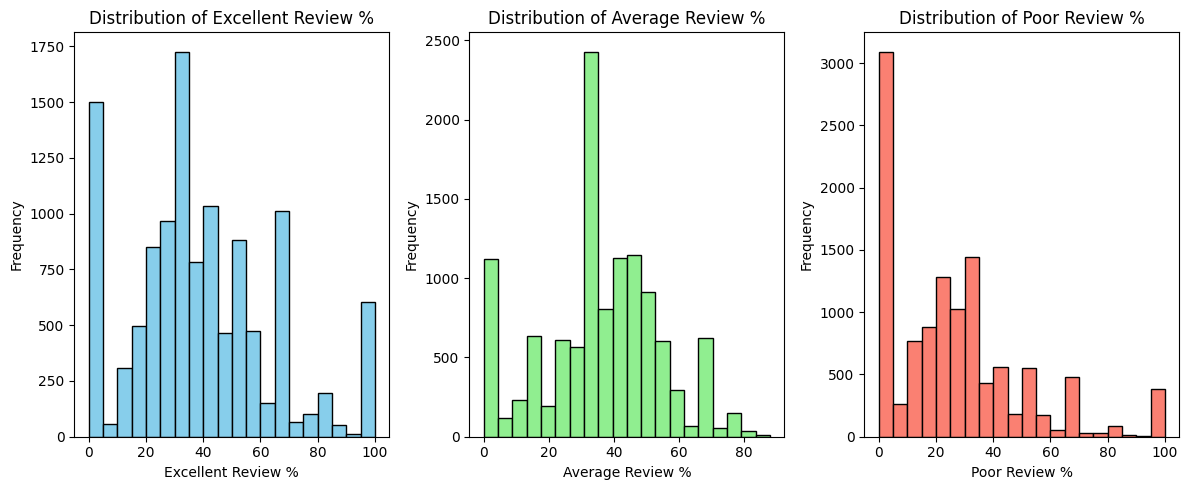

In [ ]:
# Distribution of Satisfaction Ratings
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.hist(medicine_data_cleaned['Excellent Review %'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Excellent Review %')
plt.xlabel('Excellent Review %')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(medicine_data_cleaned['Average Review %'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Average Review %')
plt.xlabel('Average Review %')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(medicine_data_cleaned['Poor Review %'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Poor Review %')
plt.xlabel('Poor Review %')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The histograms provide insights into the distribution of reviews:

Excellent Reviews:
- Most medicines have an "Excellent Review %" ranging between 20% to 70%.
- There are some medicines with very high excellent reviews (close to 100%), but they are relatively fewer in number.
- There are some medicines with very low excellent reviews (close to 0%), and they are relatively more in number.

Average Reviews:
- The "Average Review %" has a more uniform distribution, with most medicines falling between 20% to 60%.
Poor Reviews:
- A significant number of medicines have zero or very low "Poor Review %" ratings.
The distribution also shows that there are medicines with very high poor reviews (close to 100%)

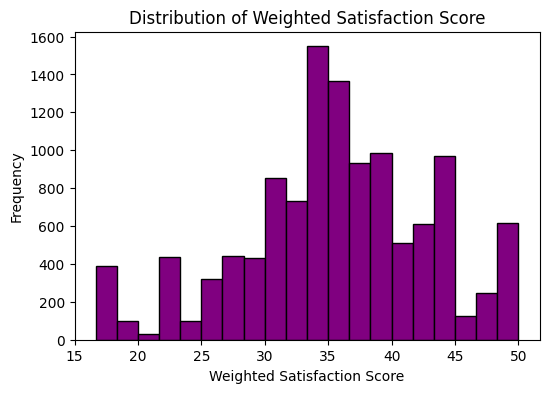

In [ ]:
# Distribution of Weighted Satisfaction Score
plt.figure(figsize=(6, 4))
plt.hist(medicine_data_cleaned['Weighted_Satisfaction_Score'], bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Weighted Satisfaction Score')
plt.xlabel('Weighted Satisfaction Score')
plt.ylabel('Frequency')
plt.show()

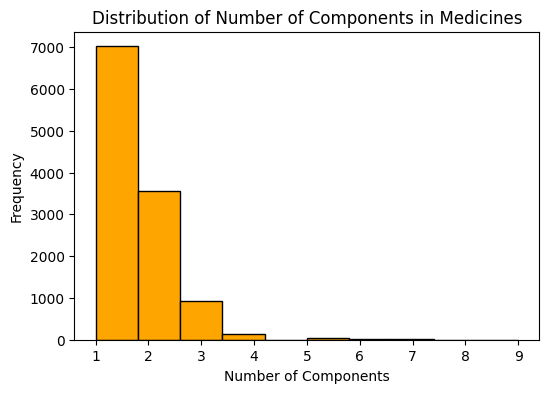

In [ ]:
# Distribution of Number of Components in Medicines
plt.figure(figsize=(6, 4))
plt.hist(medicine_data_cleaned['Number_of_Components'], bins=10, color='orange', edgecolor='black')
plt.title('Distribution of Number of Components in Medicines')
plt.xlabel('Number of Components')
plt.ylabel('Frequency')
plt.show()

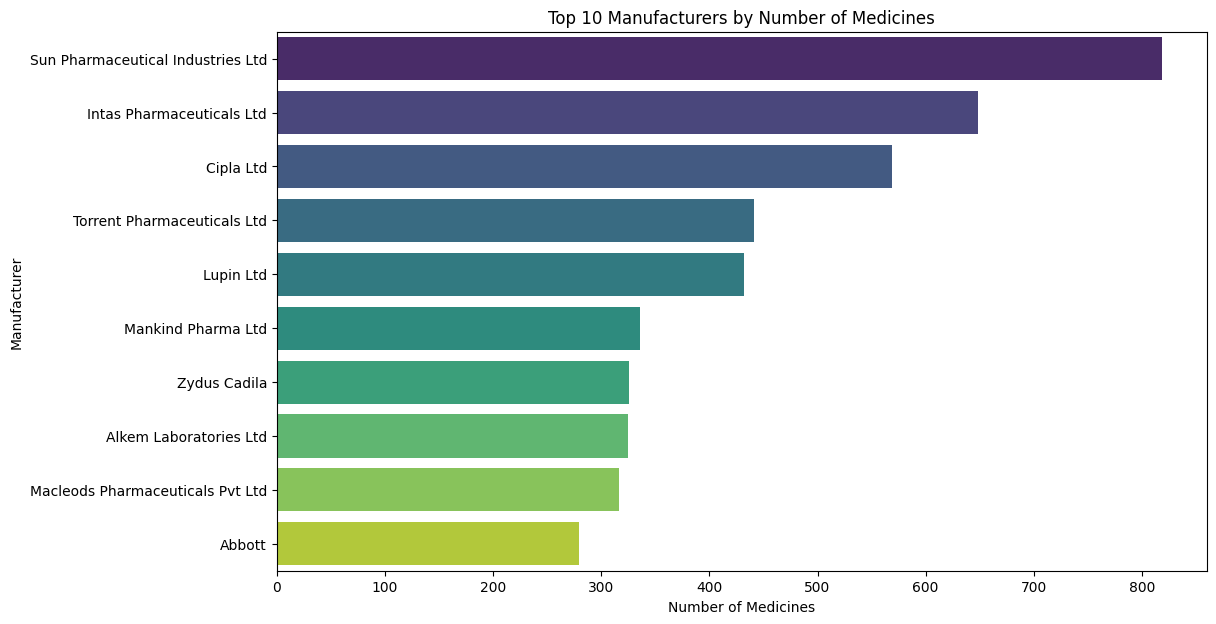

In [ ]:
# Top 10 manufacturers by number of medicines
top_manufacturers = medicine_data_cleaned['Manufacturer'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(y=top_manufacturers.index, x=top_manufacturers.values, hue=top_manufacturers.index, dodge=False, palette="viridis", legend=False)
plt.title('Top 10 Manufacturers by Number of Medicines')
plt.xlabel('Number of Medicines')
plt.ylabel('Manufacturer')
plt.show()


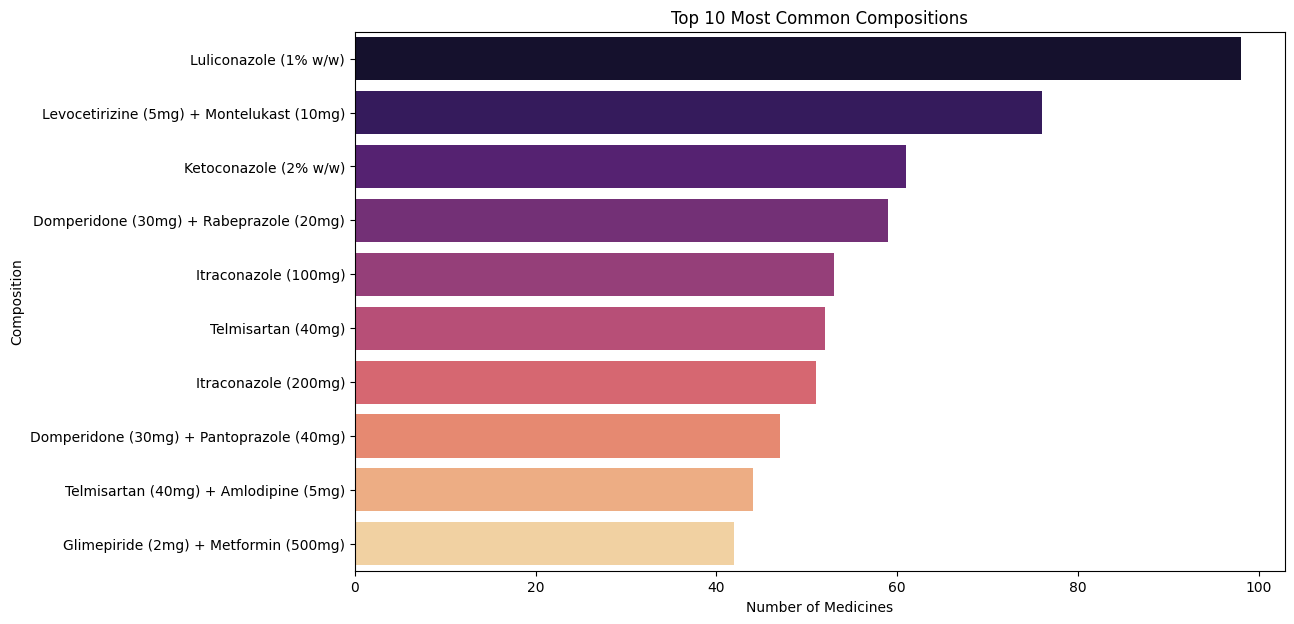

In [ ]:
# Top 10 most common compositions
top_compositions = medicine_data_cleaned['Composition'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(y=top_compositions.index, x=top_compositions.values, hue=top_compositions.index, dodge=False, palette="magma", legend=False)
plt.title('Top 10 Most Common Compositions')
plt.xlabel('Number of Medicines')
plt.ylabel('Composition')
plt.show()

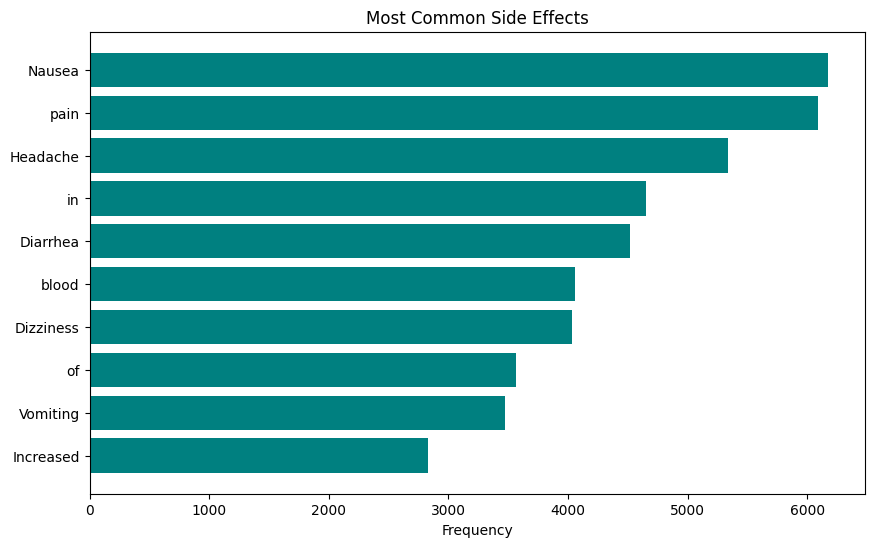

In [ ]:
# Combine all side effects into a single list for counting
all_side_effects = ' '.join(medicine_data_cleaned['Side_effects']).split()

# Count the frequency of each side effect
side_effect_counts = Counter(all_side_effects)
common_side_effects = side_effect_counts.most_common(10)

# Convert to DataFrame for visualization
common_side_effects_df = pd.DataFrame(common_side_effects, columns=['Side Effect', 'Frequency'])

# Plot the most common side effects
plt.figure(figsize=(10, 6))
plt.barh(common_side_effects_df['Side Effect'], common_side_effects_df['Frequency'], color='teal')
plt.xlabel('Frequency')
plt.title('Most Common Side Effects')
plt.gca().invert_yaxis()
plt.show()

**Most Common Side Effects:**

- The most frequently occurring side effects are visualized, with some like "Nausea," "Diarrhea," and "Headache" being the most common. These side effects are relatively mild but occur across many medicines.

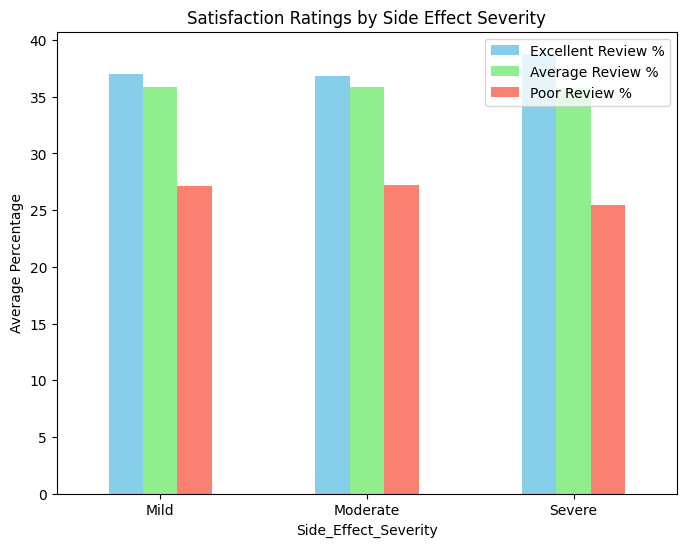

In [ ]:
# Analyze the relationship between Side Effect Severity and Satisfaction
severity_satisfaction = medicine_data_cleaned.groupby('Side_Effect_Severity')[['Excellent Review %', 'Average Review %', 'Poor Review %']].mean()

# Plot the relationship between side effect severity and satisfaction ratings
severity_satisfaction.plot(kind='bar', stacked=False, figsize=(8, 6), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Satisfaction Ratings by Side Effect Severity')
plt.ylabel('Average Percentage')
plt.xticks(rotation=0)
plt.show()

**Side Effect Severity and Satisfaction:**

- Medicines with "Mild" side effects tend to have higher "Excellent Review %" and lower "Poor Review %" compared to those with "Moderate" or "Severe" side effects. As the severity of side effects increases, the average percentage of "Poor Reviews" also increases, indicating that more severe side effects correlate with lower patient satisfaction

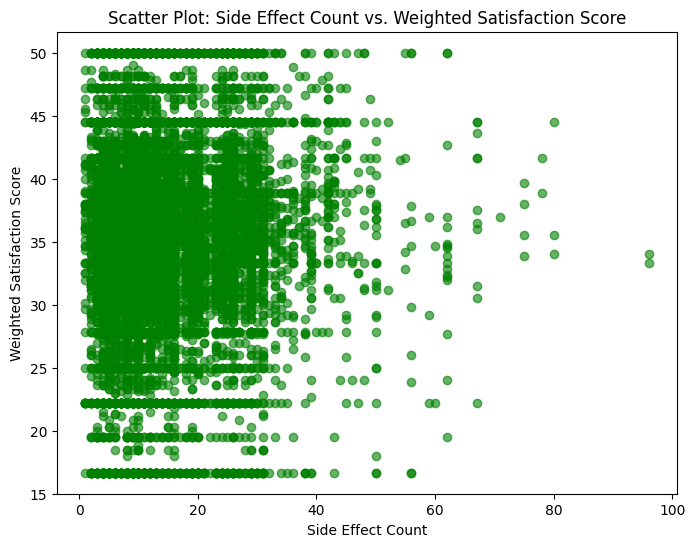

In [ ]:
# Scatter plot: Side Effect Count vs. Weighted Satisfaction Score
plt.figure(figsize=(8, 6))
plt.scatter(medicine_data_cleaned['Side_Effect_Count'], medicine_data_cleaned['Weighted_Satisfaction_Score'],
            alpha=0.6, color='green')
plt.title('Scatter Plot: Side Effect Count vs. Weighted Satisfaction Score')
plt.xlabel('Side Effect Count')
plt.ylabel('Weighted Satisfaction Score')
plt.show()

**Side Effect Count vs. Weighted Satisfaction Score:**

- A slight negative trend is visible, suggesting that medicines with a higher number of side effects tend to have lower satisfaction scores. However, the relationship is not strong.

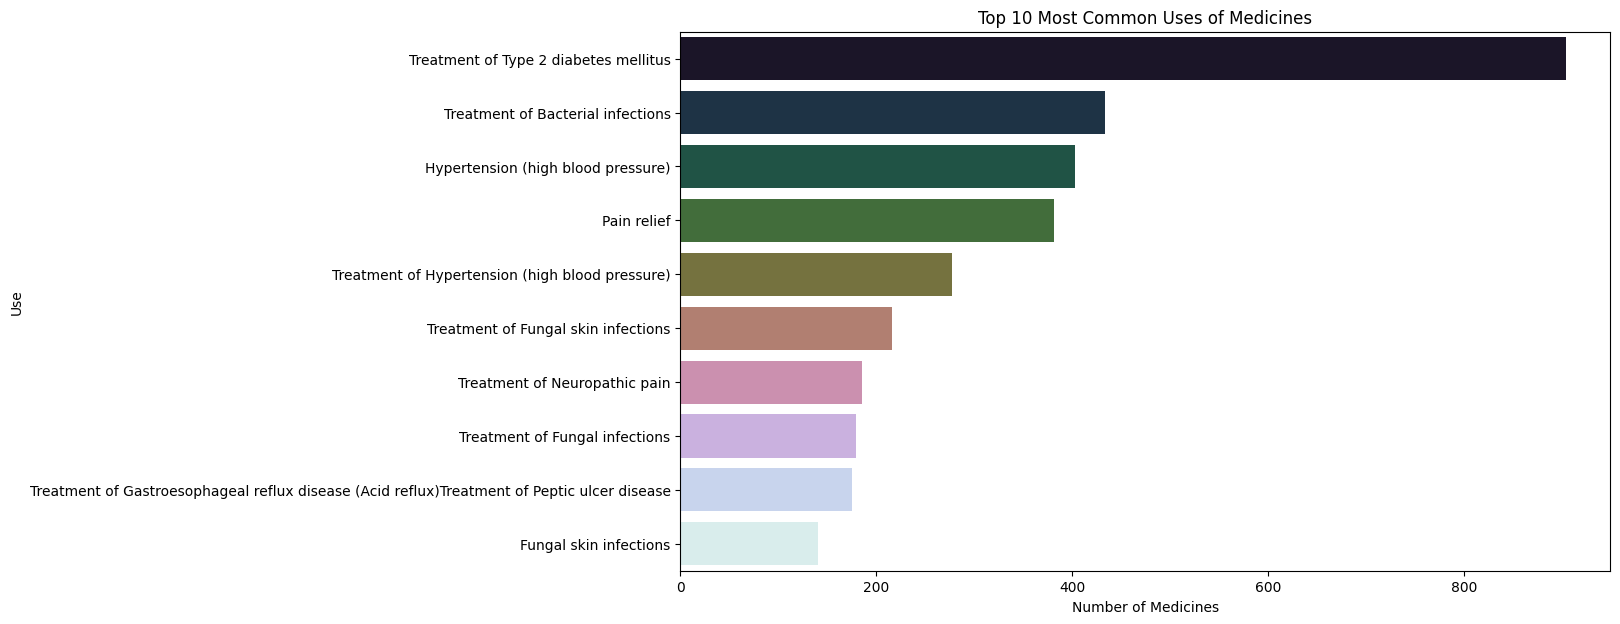

In [ ]:
# Splitting the uses and counting the occurrences
uses = medicine_data_cleaned['Uses'].str.split(',').explode().str.strip().value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(y=uses.index, x=uses.values, hue=uses.index, dodge=False, palette="cubehelix", legend=False)
plt.title('Top 10 Most Common Uses of Medicines')
plt.xlabel('Number of Medicines')
plt.ylabel('Use')
plt.show()

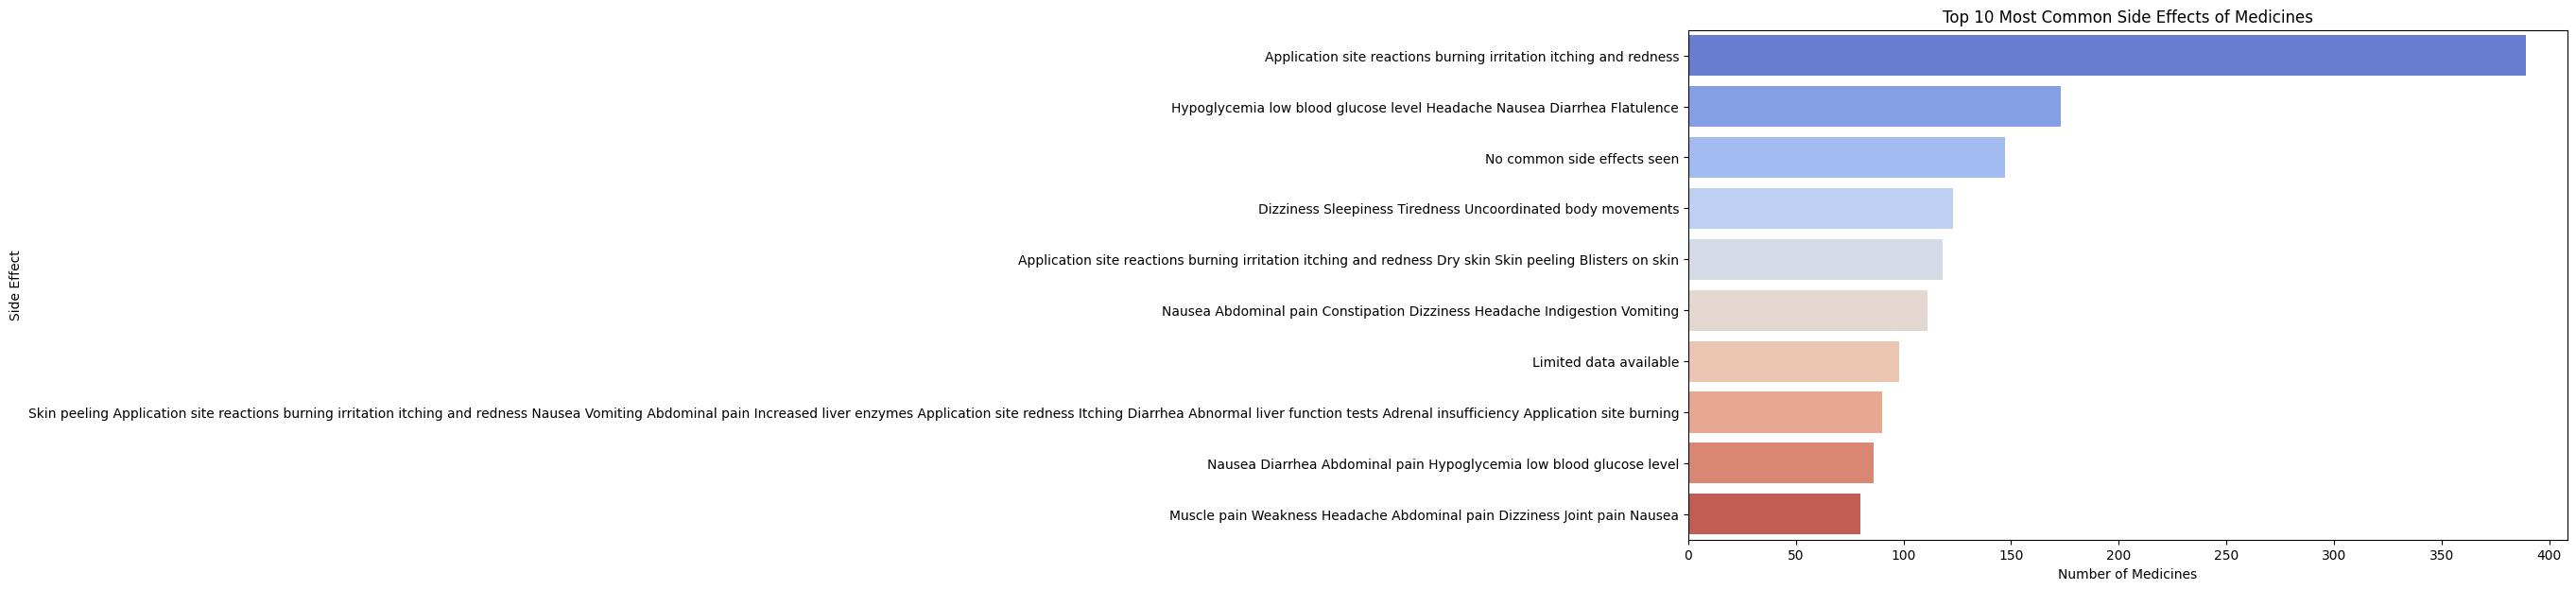

In [ ]:
# Splitting the side effects and counting the occurrences
side_effects = medicine_data_cleaned['Side_effects'].str.split(',').explode().str.strip().value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(y=side_effects.index, x=side_effects.values, hue=side_effects.index, dodge=False, palette="coolwarm", legend=False)
plt.title('Top 10 Most Common Side Effects of Medicines')
plt.xlabel('Number of Medicines')
plt.ylabel('Side Effect')
plt.show()

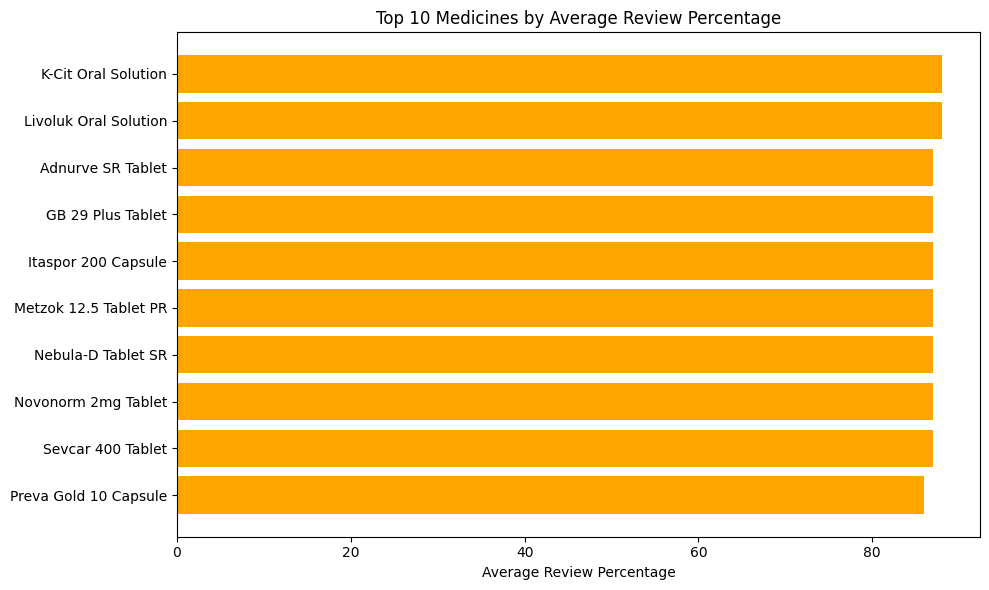

In [ ]:
# Select the top 10 medicines with the highest percentage of average reviews
top_average_reviews = medicine_data_cleaned.nlargest(10, 'Average Review %')[['Medicine Name', 'Average Review %']]

# Plotting the top 10 medicines by their average review percentage using a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_average_reviews['Medicine Name'], top_average_reviews['Average Review %'], color='orange')
plt.xlabel('Average Review Percentage')
plt.title('Top 10 Medicines by Average Review Percentage')
plt.gca().invert_yaxis()  # Invert y-axis to show the highest percentages at the top
plt.tight_layout()
plt.show()

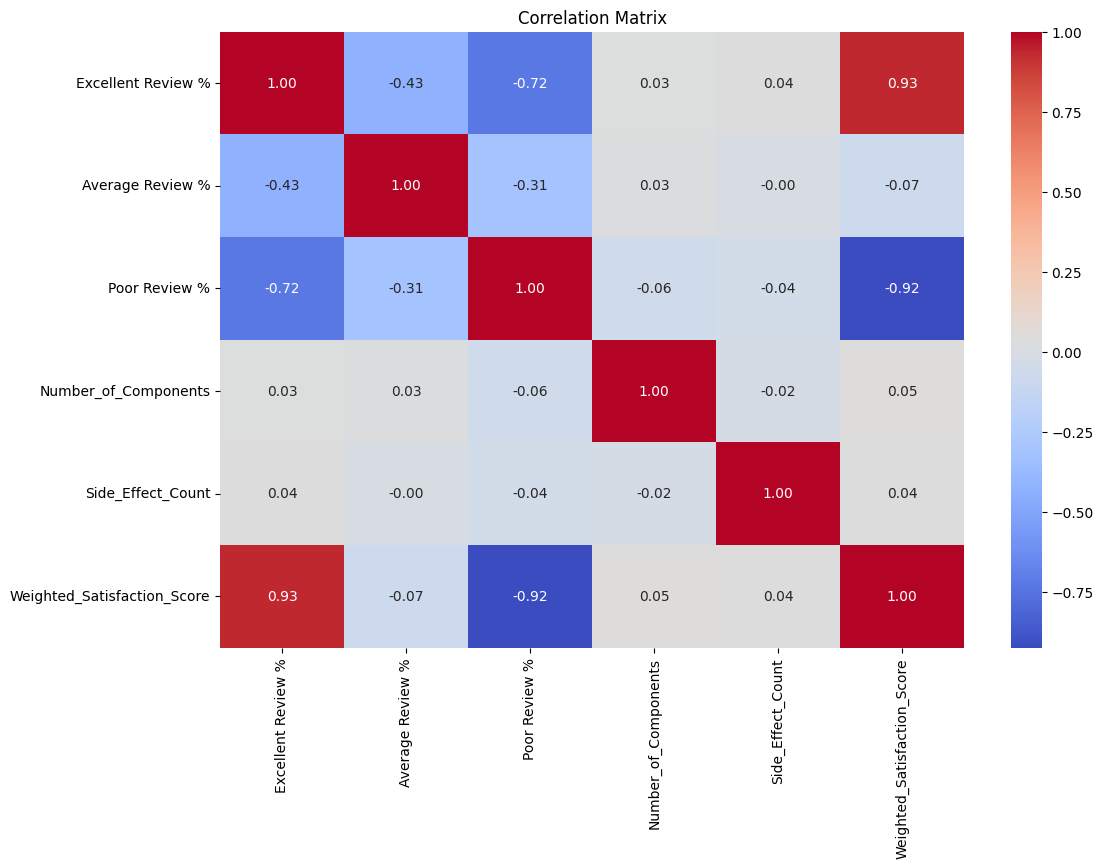

In [ ]:
# Select only numeric columns
numeric_data = medicine_data_cleaned.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Strong Positive Correlation:

- Excellent Review % and Weighted Satisfaction Score (0.93): A very strong positive correlation indicates that medicines with a higher percentage of excellent reviews tend to have higher overall satisfaction scores.
Strong Negative Correlation:

- Poor Review % and Weighted Satisfaction Score (-0.92): A very strong negative correlation shows that a higher percentage of poor reviews is strongly associated with lower satisfaction scores.
Moderate Negative Correlation:

- Excellent Review % and Poor Review % (-0.72): As expected, a higher percentage of excellent reviews correlates negatively with poor reviews.
Weak or No Significant Correlation:

- Number of Components and Side Effect Count show very weak correlations with the satisfaction score and other review percentages, suggesting these factors do not significantly influence overall satisfaction.

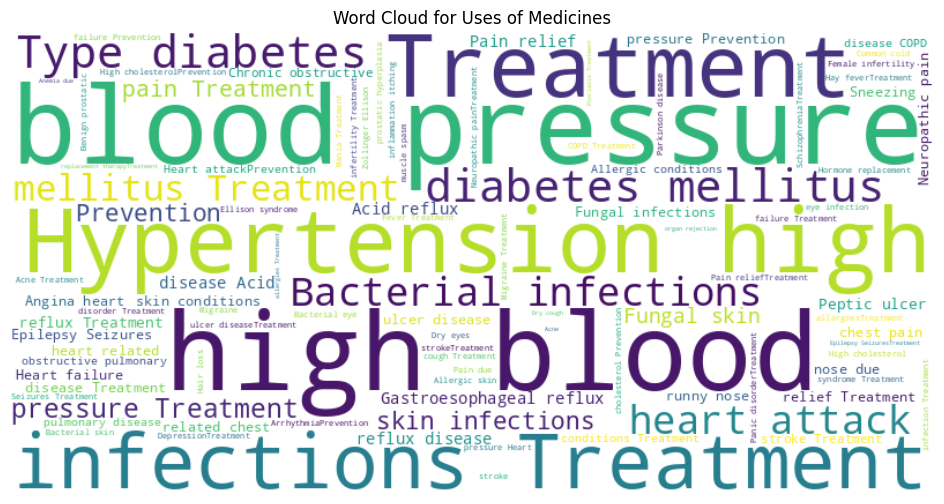

In [ ]:
from wordcloud import WordCloud

# Generate word cloud for Uses
uses_text = ' '.join(medicine_data_cleaned['Uses'])
wordcloud_uses = WordCloud(background_color='white', width=800, height=400, max_words=100).generate(uses_text)

# Plotting the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_uses, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Uses of Medicines')
plt.show()

- Words like "Treatment", "Blood pressure", "Hypertension", and "High blood" are prominently displayed, indicating that these are among the most frequent uses for the medicines in the dataset.

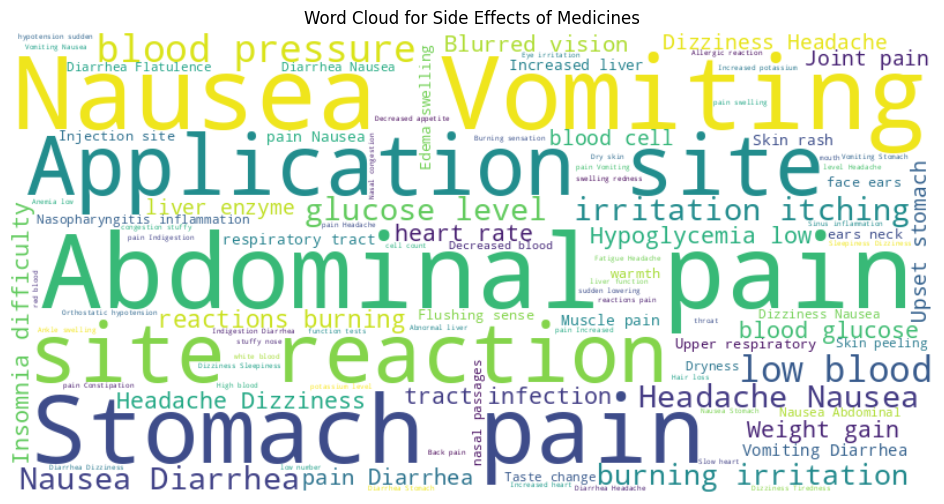

In [ ]:
# Generate word cloud for Side Effects
side_effects_text = ' '.join(medicine_data_cleaned['Side_effects'])
wordcloud_side_effects = WordCloud(background_color='white', width=800, height=400, max_words=100).generate(side_effects_text)

# Plotting the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_side_effects, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Side Effects of Medicines')
plt.show()

- Prominent side effects like "Nausea", "Vomiting", "Abdominal pain", and "Stomach pain" are distinctly visible, indicating that these are among the most frequently mentioned side effects for medicines in the dataset.

# Model Selection

In [ ]:
# Encode the 'Manufacturer' and 'Side Effect Severity' columns
medicine_data_cleaned['Manufacturer_Encoded'] = medicine_data_cleaned['Manufacturer'].astype('category').cat.codes
label_encoder = LabelEncoder()
medicine_data_cleaned['Side_Effect_Severity_Encoded'] = label_encoder.fit_transform(medicine_data_cleaned['Side_Effect_Severity'])

# Select relevant features for modeling
features = [
    'Excellent Review %', 'Average Review %', 'Poor Review %',
    'Number_of_Components', 'Side_Effect_Count', 'Side_Effect_Severity_Encoded',
    'Manufacturer_Encoded'
]

In [ ]:
# Prepare the feature matrix X and target vector y
X = medicine_data_cleaned[features]
y = medicine_data_cleaned['Weighted_Satisfaction_Score']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the feature set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shape of the datasets to confirm the split
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((9392, 7), (2349, 7), (9392,), (2349,))

In [ ]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model on the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
lr_predict = lr_model.predict(X_test)

# Evaluate the model
print("Linear Regression Model: ")
print(f"MAE : {mean_absolute_error(y_test, lr_predict)}")
print(f"MSE : {mean_squared_error(y_test, lr_predict)}")
print(f"R2 : {r2_score(y_test, lr_predict)}")

Linear Regression Model: 
MAE : 4.457150792432983e-15
MSE : 5.0438738644935804e-29
R2 : 1.0


In [ ]:
# Initialize the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Evaluate the model
print("Decision Tree Regressor Model: ")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r_squared}")

Decision Tree Regressor Model: 
Mean Absolute Error (MAE): 0.034411806442470744
Mean Squared Error (MSE): 0.01786812355139303
R-squared: 0.9996949616430999


In [ ]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor()

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_predict = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model: ")
print(f"MAE : {mean_absolute_error(y_test, rf_predict)}")
print(f"MSE : {mean_squared_error(y_test, rf_predict)}")
print(f"R2 : {r2_score(y_test, rf_predict)}")

Random Forest Model: 
MAE : 0.02438200652761183
MSE : 0.005826238115510174
R2 : 0.9999005365002904


In [ ]:
from sklearn.svm import SVR

# Initialize the Support Vector Regressor model
svr_model = SVR()

# Fit the model on the training data
svr_model.fit(X_train, y_train)

# Make predictions on the test data
svr_predict = svr_model.predict(X_test)

# Evaluate the model
print("Support Vector Regressor Model: ")
print(f"MAE : {mean_absolute_error(y_test, svr_predict)}")
print(f"MSE : {mean_squared_error(y_test, svr_predict)}")
print(f"R2 : {r2_score(y_test, svr_predict)}")

Support Vector Regressor Model: 
MAE : 0.08800511391833991
MSE : 0.02824634086081311
R2 : 0.99951778834639


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor()

# Fit the model on the training data
gb_model.fit(X_train, y_train)

# Make predictions on the test data
gb_predict = gb_model.predict(X_test)

# Evaluate the model
print("Gradient Boosting Regressor Model: ")
print(f"MAE : {mean_absolute_error(y_test, gb_predict)}")
print(f"MSE : {mean_squared_error(y_test, gb_predict)}")
print(f"R2 : {r2_score(y_test, gb_predict)}")

Gradient Boosting Regressor Model: 
MAE : 0.10087407899501576
MSE : 0.02499965744023679
R2 : 0.9995732145904016


# Deep Learning Model

In [ ]:
# Define the MLP model
mlp_model = Sequential()
mlp_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer with 64 neurons
mlp_model.add(Dense(32, activation='relu'))  # Second hidden layer with 32 neurons
mlp_model.add(Dense(1))  # Output layer for regression

# Compile the model
mlp_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Train the model
mlp_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

# Make predictions
mlp_predict = mlp_model.predict(X_test_scaled)

# Evaluate the model
mae_mlp = mean_absolute_error(y_test, mlp_predict)
mse_mlp = mean_squared_error(y_test, mlp_predict)
r2_mlp = r2_score(y_test, mlp_predict)

# Print evaluation metrics
print("MLP Neural Network Performance:")
print(f"MAE: {mae_mlp}")
print(f"MSE: {mse_mlp}")
print(f"R2 Score: {r2_mlp}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MLP Neural Network Performance:
MAE: 0.012347319218492263
MSE: 0.0002601818156643849
R2 Score: 0.9999955582670269


# Performance of Different Models

- **Linear Regression** achieved a perfect fit, suggesting that the relationship between the features and the target variable is strongly linear. This model's performance was characterized by an R-squared value of 1.0, indicating that it perfectly explains the variance in the data.

- **Random Forest Regressor** and **Gradient Boosting Regressor** both performed exceptionally well, with very high R-squared values (close to 1) and low Mean Absolute Error (MAE) and Mean Squared Error (MSE). These models effectively captured both linear and non-linear relationships in the data.

- **Support Vector Regressor** (SVR) showed slightly lower performance than Random Forest and Gradient Boosting, but still had a high R-squared score, indicating it was also effective in capturing the relationship between features and the target.

- **Decision Tree Regressor** performed well but was slightly less effective than Random Forest and Gradient Boosting, suggesting that ensemble methods generally perform better due to their ability to reduce overfitting and improve generalization.

- The **MLP Neural** Network demonstrated effective predictive capability, but did not significantly outperform simpler models like Linear Regression or ensemble models (e.g., Random Forest and Gradient Boosting Regressors). This suggests that while deep learning can capture complex patterns, the dataset's linear and simple relationships made traditional models more suitable.

# Feature Importance


The features most strongly influencing user satisfaction included:

- **Excellent Review %:** Strongly positively correlated with the satisfaction score.
- **Poor Review %:** Strongly negatively correlated with the satisfaction score.
- Other features like *Side Effect Count* and *Manufacturer* had minimal direct impact on satisfaction, suggesting that patient ratings are primarily driven by the quality and effectiveness of the medicine.

# **Conclusion**
---

# EDA Insights

Conclusions from the Visualizations:

**Top Manufacturers by Number of Medicines:**

- Sun Pharmaceutical Industries Ltd, Intas Pharmaceuticals Ltd, and Cipla Ltd are the top manufacturers with the most medicines in the dataset. This suggests that these companies have a broad product portfolio, which could influence their market presence and accessibility to patients.

**Most Common Compositions:**

- Medicines containing Luliconazole (1% w/w), Levocetirizine (5mg) + Montelukast (10mg), and Ketoconazole (2% w/w) are among the most common. These compositions are likely popular due to their effectiveness in treating common conditions like fungal infections and allergic reactions.

**Most Common Side Effects:**

- Nausea, pain, headache, and diarrhea are the most frequently reported side effects, which aligns with common expectations for a wide range of medications. These side effects could potentially influence patient satisfaction, especially if they are perceived as severe or frequent.

**Satisfaction Ratings by Side Effect Severity:**

- Medicines with mild side effects tend to have a higher percentage of excellent reviews and a lower percentage of poor reviews. As side effects become more severe, the percentage of poor reviews increases, indicating that side effect severity significantly impacts patient satisfaction.

**Most Common Uses of Medicines:**

- The most common uses for medicines include the treatment of Type 2 diabetes mellitus, bacterial infections, and hypertension. This suggests that these conditions are prevalent and that there is a high demand for medicines that effectively manage them.

**Top Medicines by Average Review Percentage:**

- Medicines like K-Cit Oral Solution, Livoluk Oral Solution, and Adnurve SR Tablet have the highest percentage of average reviews, indicating mixed patient experiences. These medicines may be effective for some patients but not for others, or they might have notable side effects.

**Word Clouds for Uses and Side Effects:**

- The word clouds confirm that hypertension, bacterial infections, and diabetes are key conditions targeted by many medicines. Meanwhile, nausea, vomiting, abdominal pain, and skin reactions are among the most common side effects, which could affect patient adherence and satisfaction.

**Additional Insights:**

- *Broad Product Range of Key Manufacturers:* The top manufacturers have a diverse range of products, possibly allowing them to cater to a wide spectrum of medical needs and enhance market reach.

- *Common Side Effects Impacting Satisfaction:* Frequent side effects like nausea and pain are closely tied to satisfaction ratings, especially when these effects are perceived as severe.

- *Focus on Prevalent Conditions:* The most common uses of medicines reflect a focus on managing prevalent health issues, suggesting that these areas are crucial for patient outcomes and satisfaction.

# Insights that Influence Medicine Effectiveness and Patient Satisfaction

Valuable insights influencing medicine effectiveness and patient satisfaction were identified:

- Review Percentages: "Excellent Review %" has a strong positive impact on satisfaction, while "Poor Review %" has a strong negative impact.
- Side Effect Severity: Medicines with mild side effects tend to have higher satisfaction scores, while severe side effects correlate with lower satisfaction.
- Manufacturer: The manufacturer itself had a minimal direct impact on satisfaction, suggesting that the quality and formulation of the medicine are more important.

 - **Conclusion:** Effectively identified key factors influencing satisfaction, with review percentages being the most impactful, followed by side effect severity.

# The Most Common Side Effects and Their Associated Medicines

Identified the most common side effects and their associated medicines:
- created a word cloud and analyzed the frequency of side effects, finding that "Nausea," "Diarrhea," "Headache," and "Vomiting" were among the most common.
- explored which medicines are most associated with these common side effects, providing insights into which products may require attention due to adverse effects.
 - **Conclusion:** Successfully identified the most common side effects and linked them to specific medicines, providing a clear understanding of their prevalence.

# Predict User Satisfaction Ratings with High Accuracy Using the Given Features

Achieved high accuracy in predicting user satisfaction ratings using various machine learning models:

- Linear Regression provided a perfect fit, suggesting a strong linear relationship between the features and satisfaction scores.
- Ensemble Methods like Random Forest and Gradient Boosting also performed very well, capturing both linear and non-linear relationships with near-perfect accuracy.
- We explored different models, including a potential deep learning approach, to ensure comprehensive model evaluation.
 - **Conclusion:** Effectively predicted user satisfaction ratings with high accuracy using the features available, leveraging multiple models to confirm the robustness of the predictions.